In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("dataset/Student Depression Dataset.csv")
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


# understanding dataset


In [3]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [5]:
df.shape

(27901, 18)

In [6]:
df.Profession.unique()

array(['Student', 'Civil Engineer', 'Architect', 'UX/UI Designer',
       'Digital Marketer', 'Content Writer', 'Educational Consultant',
       'Teacher', 'Manager', 'Chef', 'Doctor', 'Lawyer', 'Entrepreneur',
       'Pharmacist'], dtype=object)

In [7]:
df.Profession.value_counts()

Profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

<Axes: xlabel='Depression', ylabel='count'>

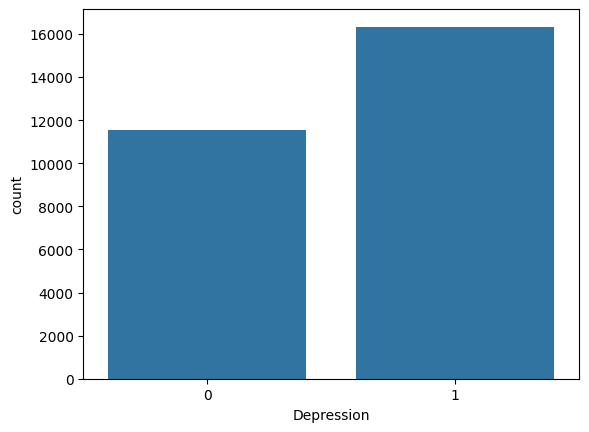

In [8]:
sns.barplot(df.Depression.value_counts())

- more than 50% of student are in depression


In [9]:
len(df[df["Depression"] == 1]["Depression"]) / len(df["Depression"]) * 100

58.549872764417046

## cleaning dataset

- there is no null values in dataset


In [10]:
df.isna().sum().sort_values()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Family History of Mental Illness         0
Depression                               0
Financial Stress                         3
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [12]:
df["Family History of Mental Illness"] = np.where(
    df["Family History of Mental Illness"] == "No", 0, 1
)
df["Family History of Mental Illness"].astype(int)

0        0
1        1
2        1
3        1
4        0
        ..
27896    1
27897    1
27898    0
27899    0
27900    1
Name: Family History of Mental Illness, Length: 27901, dtype: int64

In [13]:
df["Have you ever had suicidal thoughts ?"] = np.where(
    df["Have you ever had suicidal thoughts ?"] == "No", 0, 1
)
df["Have you ever had suicidal thoughts ?"].astype(int)

0        1
1        0
2        0
3        1
4        1
        ..
27896    1
27897    0
27898    0
27899    1
27900    1
Name: Have you ever had suicidal thoughts ?, Length: 27901, dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

## visualization of data

- male are more depression compare to female
- financial stress and Academic Pressure is correlated with depression
- student who sleep less than 5 hours has more depression


<Axes: xlabel='Gender', ylabel='count'>

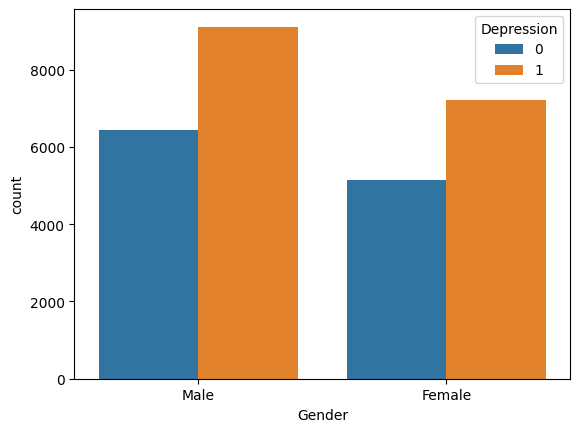

In [15]:
sns.countplot(data=df, x=df["Gender"], hue="Depression")

<Axes: xlabel='Financial Stress', ylabel='count'>

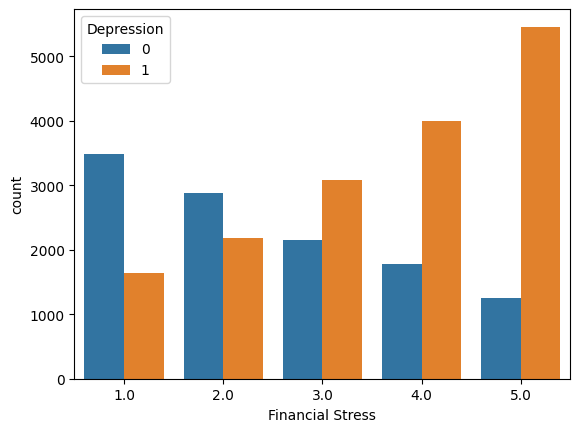

In [16]:
sns.countplot(data=df, x=df["Financial Stress"], hue="Depression")

<Axes: xlabel='Academic Pressure', ylabel='count'>

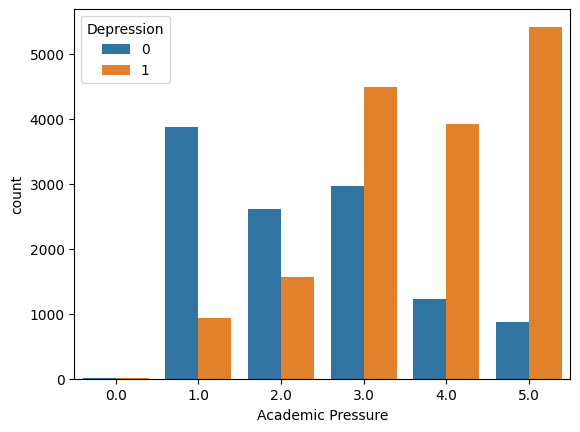

In [17]:
sns.countplot(data=df, x=df["Academic Pressure"], hue="Depression")

<Axes: xlabel='Sleep Duration', ylabel='count'>

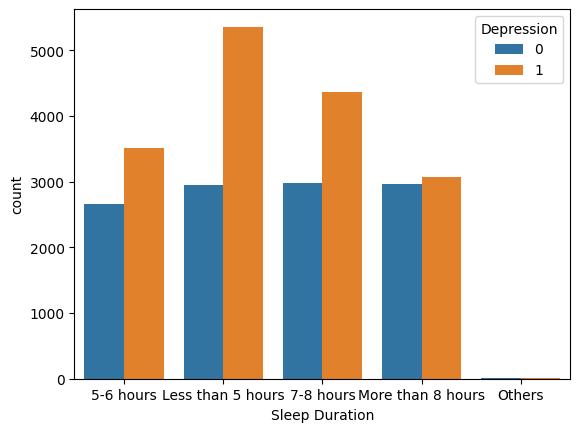

In [18]:
sns.countplot(data=df, x=df["Sleep Duration"], hue="Depression")

In [19]:
df[(df["Depression"] == 1) & (df["City"] == "Chennai")]["Depression"].count()

np.int64(528)

- these are city most of student are staying depression


<Axes: xlabel='City', ylabel='count'>

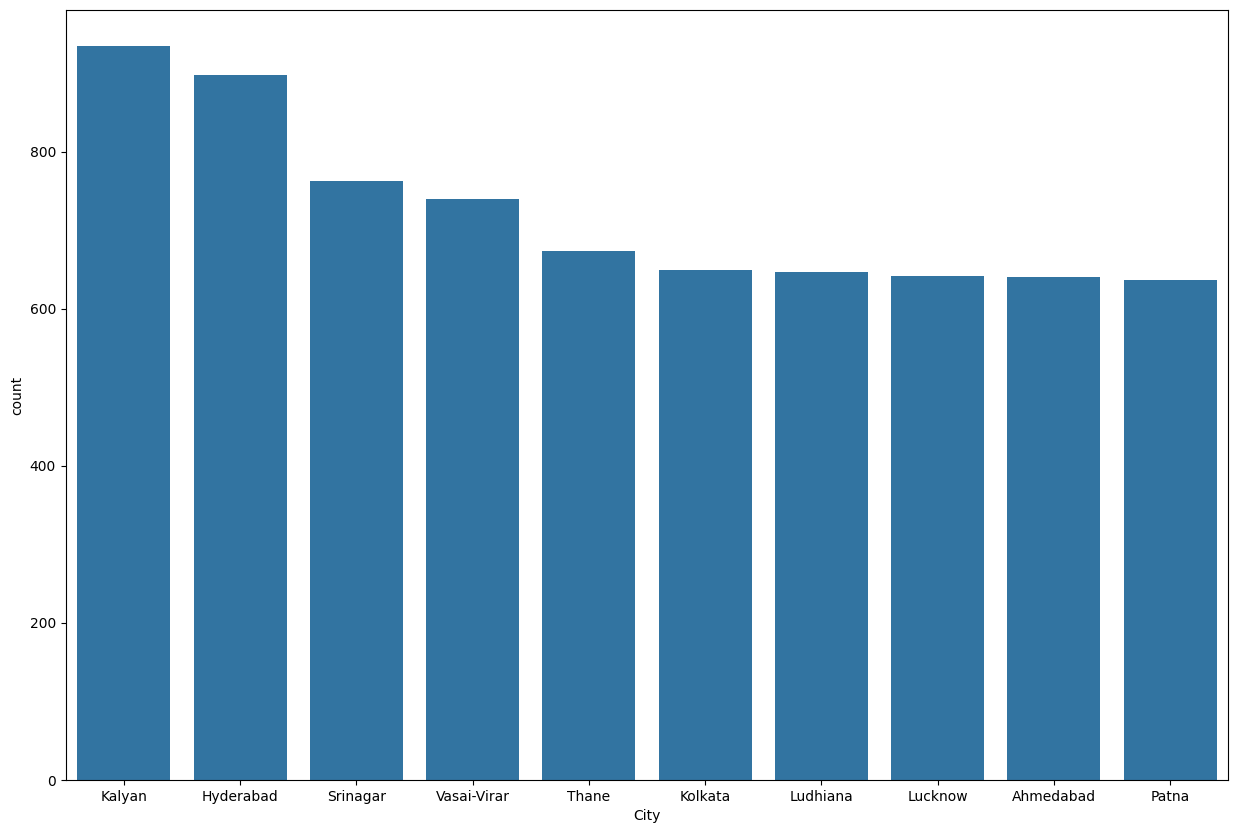

In [20]:
plt.figure(figsize=(15, 10))
sns.barplot(
    df[df["Depression"] == 1]["City"].value_counts().sort_values(ascending=False)[:10]
)

<Axes: xlabel='Family History of Mental Illness', ylabel='count'>

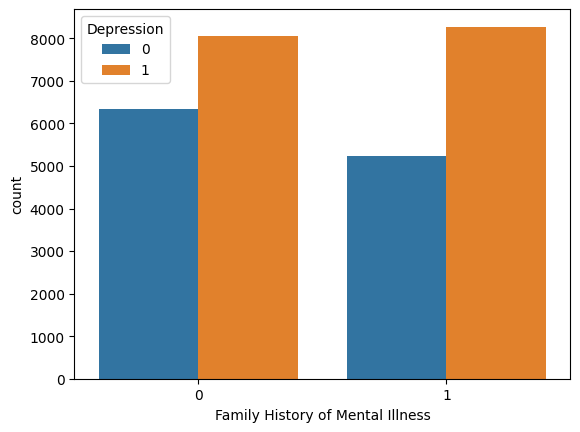

In [21]:
sns.countplot(data=df, x=df["Family History of Mental Illness"], hue="Depression")

<Axes: xlabel='Have you ever had suicidal thoughts ?', ylabel='count'>

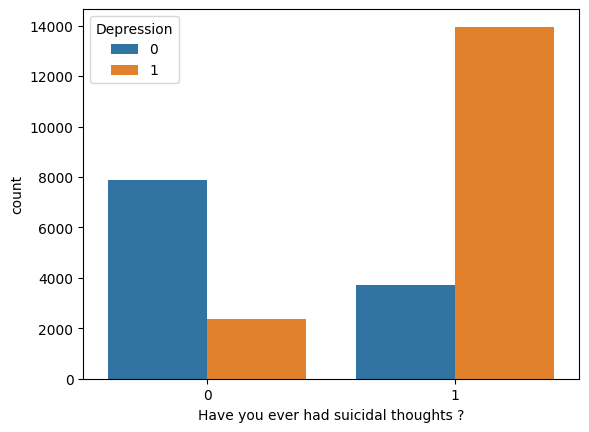

In [22]:
sns.countplot(data=df, x=df["Have you ever had suicidal thoughts ?"], hue="Depression")

In [23]:
df["Have you ever had suicidal thoughts ?"].value_counts() / len(df) * 100

Have you ever had suicidal thoughts ?
1    63.280886
0    36.719114
Name: count, dtype: float64

- more than 55% of student had suicidal throughts in whole datasets
- but 50% of student are in depression
- without depression itself student have suicide thoughts, it happen bcs some may not know that they have mental problem


In [24]:
df[(df["Have you ever had suicidal thoughts ?"] == 1)].count() / len(df) * 100

id                                       63.280886
Gender                                   63.280886
Age                                      63.280886
City                                     63.280886
Profession                               63.280886
Academic Pressure                        63.280886
Work Pressure                            63.280886
CGPA                                     63.280886
Study Satisfaction                       63.280886
Job Satisfaction                         63.280886
Sleep Duration                           63.280886
Dietary Habits                           63.280886
Degree                                   63.280886
Have you ever had suicidal thoughts ?    63.280886
Work/Study Hours                         63.280886
Financial Stress                         63.280886
Family History of Mental Illness         63.280886
Depression                               63.280886
dtype: float64

In [25]:
df[
    (df["Have you ever had suicidal thoughts ?"] == 1) & (df["Depression"] == 1)
].count() / len(df) * 100

id                                       50.023297
Gender                                   50.023297
Age                                      50.023297
City                                     50.023297
Profession                               50.023297
Academic Pressure                        50.023297
Work Pressure                            50.023297
CGPA                                     50.023297
Study Satisfaction                       50.023297
Job Satisfaction                         50.023297
Sleep Duration                           50.023297
Dietary Habits                           50.023297
Degree                                   50.023297
Have you ever had suicidal thoughts ?    50.023297
Work/Study Hours                         50.023297
Financial Stress                         50.023297
Family History of Mental Illness         50.023297
Depression                               50.023297
dtype: float64

In [26]:
df[
    (df["Have you ever had suicidal thoughts ?"] == 0) & (df["Depression"] == 1)
].count() / len(df) * 100

id                                       8.526576
Gender                                   8.526576
Age                                      8.526576
City                                     8.526576
Profession                               8.526576
Academic Pressure                        8.526576
Work Pressure                            8.526576
CGPA                                     8.526576
Study Satisfaction                       8.526576
Job Satisfaction                         8.526576
Sleep Duration                           8.526576
Dietary Habits                           8.526576
Degree                                   8.526576
Have you ever had suicidal thoughts ?    8.526576
Work/Study Hours                         8.526576
Financial Stress                         8.522992
Family History of Mental Illness         8.526576
Depression                               8.526576
dtype: float64

In [27]:
num_col = [col for col in df.columns if df[col].dtype != "O"]
num_df = df[num_col]

In [28]:
num_df

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,33.0,5.0,0.0,8.97,2.0,0.0,1,3.0,1.0,0,1
1,8,24.0,2.0,0.0,5.90,5.0,0.0,0,3.0,2.0,1,0
2,26,31.0,3.0,0.0,7.03,5.0,0.0,0,9.0,1.0,1,0
3,30,28.0,3.0,0.0,5.59,2.0,0.0,1,4.0,5.0,1,1
4,32,25.0,4.0,0.0,8.13,3.0,0.0,1,1.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,27.0,5.0,0.0,5.75,5.0,0.0,1,7.0,1.0,1,0
27897,140686,27.0,2.0,0.0,9.40,3.0,0.0,0,0.0,3.0,1,0
27898,140689,31.0,3.0,0.0,6.61,4.0,0.0,0,12.0,2.0,0,0
27899,140690,18.0,5.0,0.0,6.88,2.0,0.0,1,10.0,5.0,0,1


<Axes: >

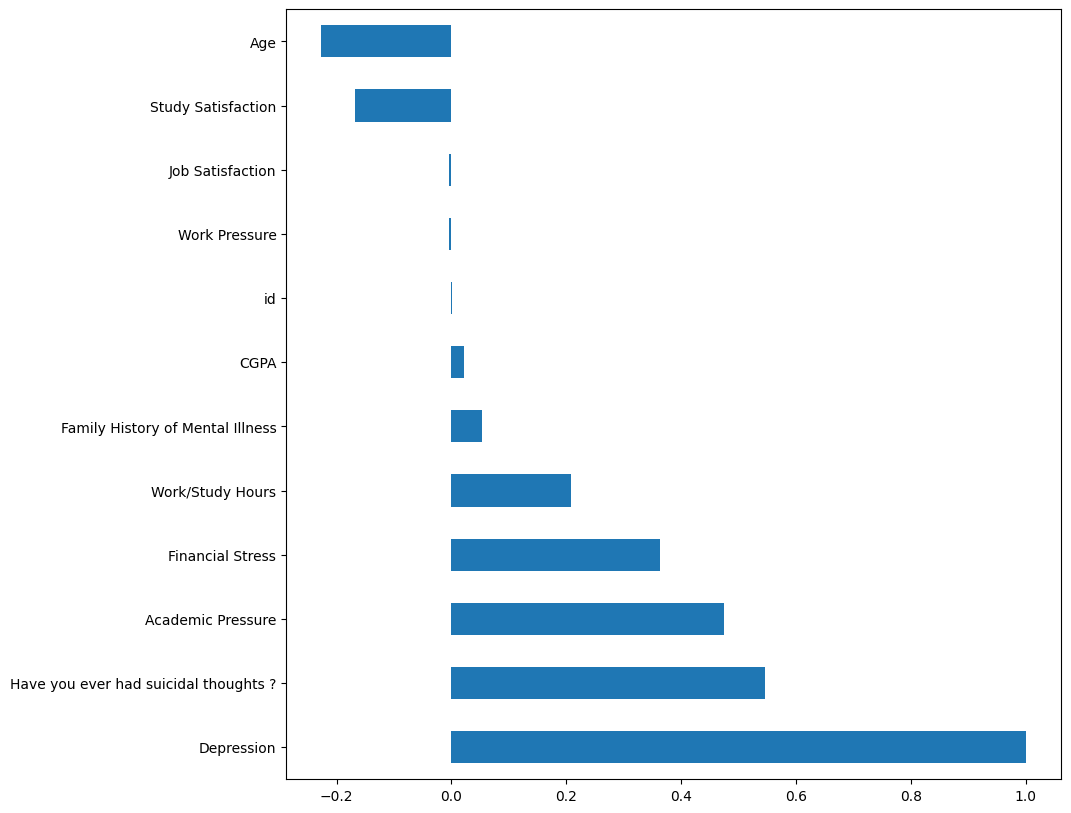

In [29]:
plt.figure(figsize=(10, 10))
num_df.corr()["Depression"].sort_values(ascending=False).plot(kind="barh")

<Axes: xlabel='Age', ylabel='Density'>

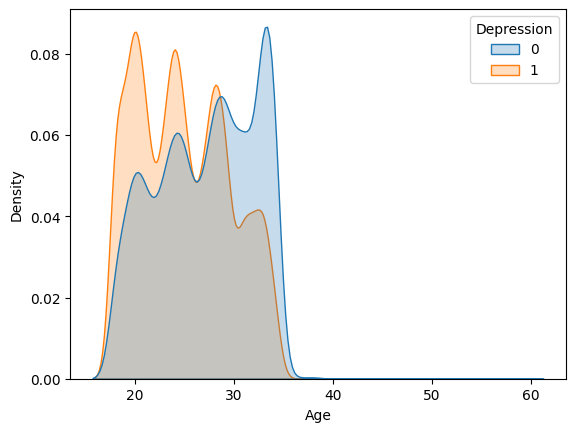

In [30]:
sns.kdeplot(data=df, x="Age", hue="Depression", common_norm=False, fill=True)

- depressed student have les CGPA or bcs of less CGPA, student are in depression


<Axes: xlabel='CGPA', ylabel='Density'>

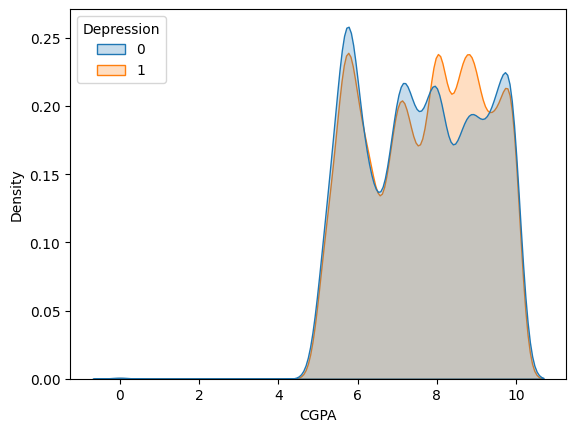

In [31]:
sns.kdeplot(data=df, x="CGPA", hue="Depression", common_norm=False, fill=True)

<Axes: xlabel='Academic Pressure', ylabel='Density'>

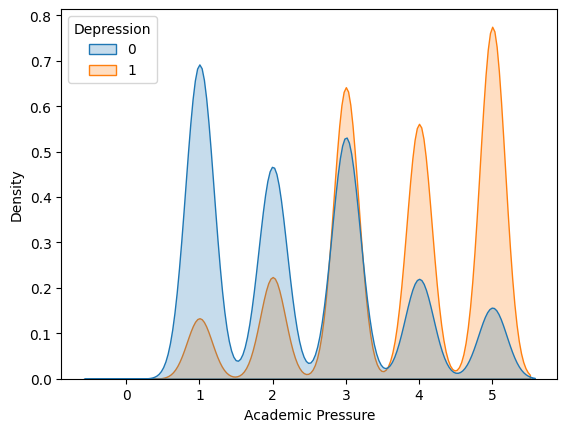

In [32]:
sns.kdeplot(
    data=df, x="Academic Pressure", hue="Depression", common_norm=False, fill=True
)

## key insight

- academic pressure, financial stress are main reason for depression and suicide throughts
-


<Axes: >

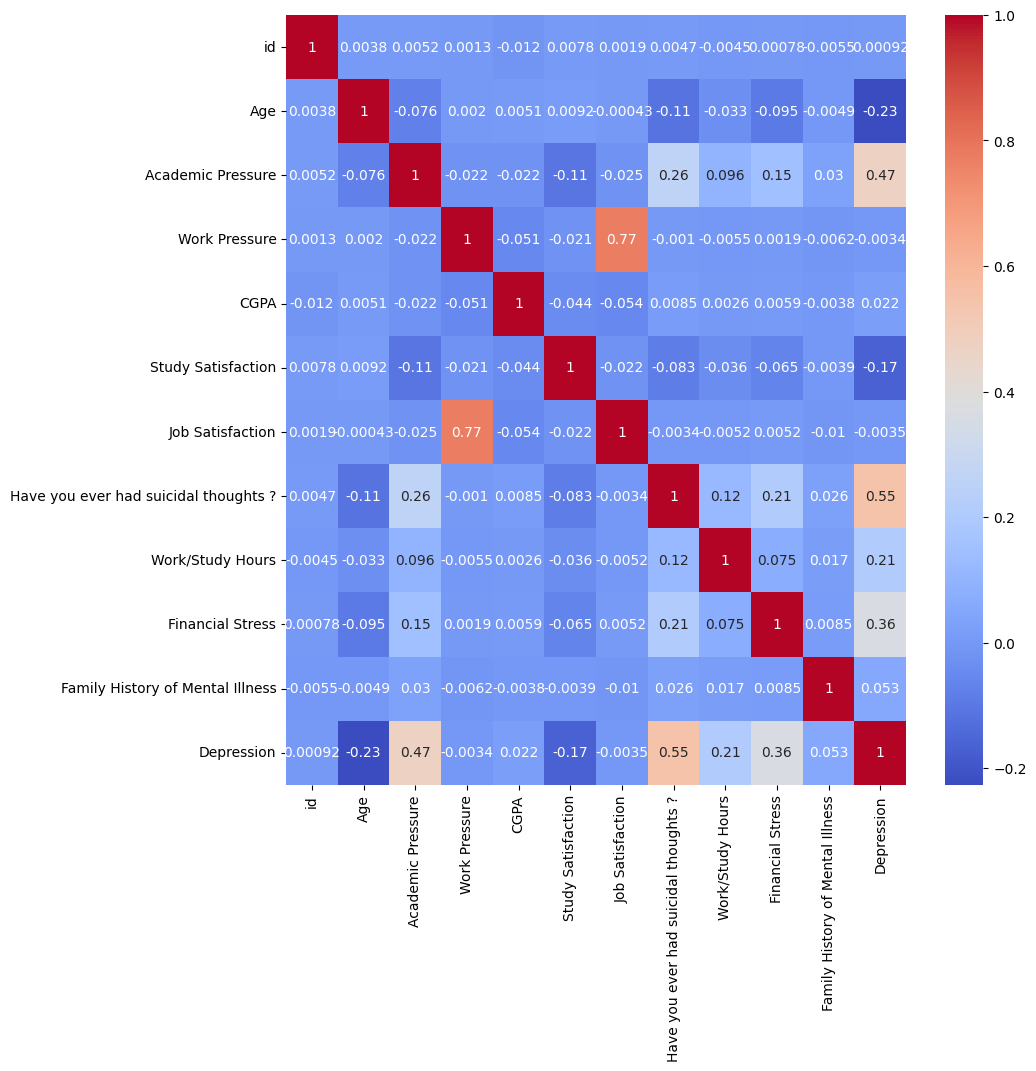

In [33]:
plt.figure(figsize=(10, 10))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")